In [16]:
from __future__ import division, print_function, absolute_import

import numpy as np
import matplotlib.pyplot as plt

import importlib
import nptdms
import pickle

from os import path

from peak_finder import utilities as util
from peak_finder import generate_lorentz as gl
from peak_finder import generate_data as gd
from peak_finder import classify_data as cd
from peak_finder import efficient_data_generation as ed
from peak_finder import data_spy as ds
from peak_finder import sliding_window as sw
from peak_finder import train_model as tm
from peak_finder import fit_lorentz as fl
from peak_finder import live_fitting as lf
from peak_finder import track_peaks as tp
from peak_finder import background_removal as br
from peak_finder import automatic
from peak_finder import models

importlib.reload(util)
importlib.reload(gl)
importlib.reload(gd)
importlib.reload(cd)
importlib.reload(ed)
importlib.reload(sw)
importlib.reload(tm)
importlib.reload(fl)
importlib.reload(lf)
importlib.reload(tp)
importlib.reload(br)
importlib.reload(automatic)
importlib.reload(models)

<module 'peak_finder.models' from '/media/gabriel/Bulk Disk/ML-Peak-Tracker/peak_finder/models.py'>

In [14]:
data_files = util.import_tdms_files()
print(str(len(data_files)) + ' files imported')

177 files imported


In [17]:
selections = lf.color_selection(data_files)

Traceback (most recent call last):
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/cbook/__init__.py", line 196, in process
    func(*args, **kwargs)
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/widgets.py", line 2613, in onmove
    self._onmove(event)
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/widgets.py", line 2644, in _onmove
    x0, y0 = self.line.get_transform().transform((self._xs[0],
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/transforms.py", line 1405, in transform
    res = self.transform_affine(self.transform_non_affine(values))
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/transforms.py", line 2365, in transform_affine
    return self.get_affine().transform(points)
  File "/home/gabriel/.local/lib/python3.8/site-packages/matplotlib/transforms.py", line 1716, in transform
    return self.transform_affine(values)
  File "/home/gabriel/.local/lib/python3.8/site-pack

In [18]:
all_peaks = fl.parameters_from_selections(data_files, selections)

Checking for Degeneracies: [============================================================] 1/1

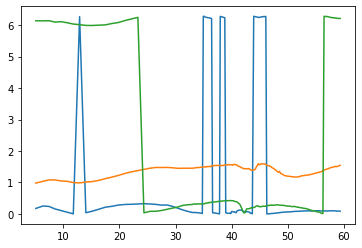

In [23]:
for i in range(0, len(all_peaks[0])):
    y = all_peaks[...,i,3]
    x = tp.get_temperatures(data_files)
    plt.plot(x, y)

In [15]:
util.save(all_peaks)

'/media/gabriel/Bulk Disk/tmd_peaks_demo.pkl'

In [16]:
tmd_peaks_demo = util.load()